# Imports

In [274]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from utils_modeling import (run_gridsearch, DataCleaner)
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
SEED = 23

pd.options.display.float_format = '{:.3f}'.format
pd.options.display.max_columns = None

In [128]:
%cd ..
data = pd.read_csv('Datasets/donors_train.csv')
data.head()
%cd Modeling (IGNORAR PARA JÁ)

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\Modeling (IGNORAR PARA JÁ)


# Other/Extra

## Modeling

### NaN

In [249]:
num_cols = data.select_dtypes(include=np.number).columns.drop([
    'CONTROL_NUMBER', 'INCOME_GROUP', 'PEP_STAR',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'TARGET_B'])

cat_cols = list(data.select_dtypes(include='str').columns) + ['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'PEP_STAR']

In [5]:
X = data.drop(['CONTROL_NUMBER', 'TARGET_B'], axis=1)
y = data['TARGET_B']

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

In [184]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self,
                 rules:dict,
                 method:str = 'percentile'):
        self.method = method
        self.rules = rules
        self.learned_limits_ = {}

    def fit(self, X, y=None):
        for var, rules in self.rules.items():
            lower_rule = rules.get('lower')
            upper_rule = rules.get('upper')
            if self.method.lower() == 'percentile':
                lower_limit = X[var].quantile(lower_rule) if lower_rule is not None else None
                upper_limit = X[var].quantile(upper_rule) if upper_rule is not None else None
                self.learned_limits_[var] = {'lower': lower_limit, 'upper': upper_limit}
            else:
                self.learned_limits_[var] = {'lower': lower_rule, 'upper': upper_rule}
        return self
    
    def transform(self, X):
        X = X.copy()
        for var, limits in self.learned_limits_.items():
            lower = limits.get('lower')
            upper = limits.get('upper')
            X[var] = X[var].clip(lower=lower, upper=upper)
        return X
    
    # Adding this allows set_output to work
    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_
                

In [185]:
class DataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, num_cols:list):
        self.num_cols = num_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X = X.replace('?', np.nan)
        X[(X[self.num_cols] < 0)] = np.nan
        return X
    
    # Adding this allows set_output to work
    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_

In [186]:
X

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,4.000,3.000,33.000,M,0.000,1.000,H,5.000,20.000,9.000,35.000,2.000,20.000,15.000,21.000,566.000,315.000,182.037,18.000,18.000,10.000,0.000,52.000,17.000,25.000,92.000,0.000,12827.000,A,0.000,17.500,NaN,0.000,2.000,0.154,0.000,2,T,NaN
1,3.000,2.000,NaN,F,1.000,1.000,U,NaN,15.000,6.000,15.000,1.000,15.000,15.000,15.000,318.000,148.000,24.000,24.000,24.000,7.000,0.000,31.000,31.000,39.000,73.000,0.000,7787.000,N,15.000,15.000,1.000,0.250,1.000,0.100,0.000,3,R,NaN
2,4.000,2.000,NaN,F,7.000,3.000,H,4.000,10.000,17.000,79.000,11.000,12.000,5.000,40.000,1669.000,373.000,129.000,15.000,15.000,8.000,0.000,26.000,39.000,38.000,84.000,1.000,13965.000,S,0.000,10.670,0.000,0.000,3.000,0.231,1.000,1,U,NaN
3,4.000,NaN,61.000,M,13.000,1.000,H,6.000,11.000,28.000,80.000,17.000,11.000,3.000,75.000,1464.000,488.000,130.000,16.000,16.000,13.000,0.000,48.000,30.000,44.000,84.000,1.000,24123.000,A,10.000,10.000,2.000,0.286,2.000,0.111,0.000,1,U,NaN
4,6.000,0.000,75.000,M,3.000,4.000,H,3.000,7.000,9.000,27.000,5.000,7.000,5.000,22.000,936.000,249.000,24.000,17.000,17.000,13.000,0.000,52.000,NaN,66.000,90.000,1.000,15008.000,N,5.670,5.400,3.000,0.600,5.000,0.500,0.000,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,5.000,0.000,84.000,M,6.000,1.000,H,6.000,10.000,32.000,135.000,12.000,NaN,5.000,69.000,558.000,285.000,97.000,19.000,19.000,12.000,0.000,38.000,26.000,76.000,82.000,1.000,14603.000,A,10.000,NaN,1.000,0.100,2.000,0.095,6.000,2,C,3.000
13556,7.000,4.000,86.000,F,16.000,3.000,H,2.000,10.000,33.000,185.000,30.000,15.000,3.000,81.000,1116.000,274.000,130.000,17.000,17.000,16.000,0.000,42.000,40.000,30.000,36.000,1.000,21881.000,S,10.000,7.500,2.000,0.222,4.000,0.211,1.000,2,U,3.000
13557,6.000,3.000,NaN,M,2.000,3.000,U,1.000,10.000,12.000,41.000,NaN,10.000,5.000,29.000,421.000,169.000,34.000,17.000,17.000,12.000,1.000,23.000,21.000,48.000,32.000,0.000,6459.000,A,8.500,9.000,2.000,0.250,4.000,0.235,0.000,2,T,NaN
13558,6.000,3.000,NaN,M,-10.099,2.000,U,NaN,-21.834,8.000,20.000,2.000,15.000,5.000,17.000,4153.000,891.000,21.000,17.000,17.000,12.000,0.000,22.000,24.000,28.000,97.000,0.000,31378.000,N,10.000,10.000,2.000,0.500,2.000,0.286,0.000,1,NaN,NaN


In [187]:
test1 = DataCleaner(num_cols=num_cols).fit_transform(X)
test1

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,4.000,3.000,33.000,M,0.000,1.000,H,5.000,20.000,9.000,35.000,2.000,20.000,15.000,21.000,566.000,315.000,182.037,18.000,18.000,10.000,0.000,52.000,17.000,25.000,92.000,0.000,12827.000,A,0.000,17.500,NaN,0.000,2.000,0.154,0.000,2,T,NaN
1,3.000,2.000,NaN,F,1.000,1.000,U,NaN,15.000,6.000,15.000,1.000,15.000,15.000,15.000,318.000,148.000,24.000,24.000,24.000,7.000,0.000,31.000,31.000,39.000,73.000,0.000,7787.000,N,15.000,15.000,1.000,0.250,1.000,0.100,0.000,3,R,NaN
2,4.000,2.000,NaN,F,7.000,3.000,H,4.000,10.000,17.000,79.000,11.000,12.000,5.000,40.000,1669.000,373.000,129.000,15.000,15.000,8.000,0.000,26.000,39.000,38.000,84.000,1.000,13965.000,S,0.000,10.670,0.000,0.000,3.000,0.231,1.000,1,U,NaN
3,4.000,NaN,61.000,M,13.000,1.000,H,6.000,11.000,28.000,80.000,17.000,11.000,3.000,75.000,1464.000,488.000,130.000,16.000,16.000,13.000,0.000,48.000,30.000,44.000,84.000,1.000,24123.000,A,10.000,10.000,2.000,0.286,2.000,0.111,0.000,1,U,NaN
4,6.000,0.000,75.000,M,3.000,4.000,H,3.000,7.000,9.000,27.000,5.000,7.000,5.000,22.000,936.000,249.000,24.000,17.000,17.000,13.000,0.000,52.000,NaN,66.000,90.000,1.000,15008.000,N,5.670,5.400,3.000,0.600,5.000,0.500,0.000,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,5.000,0.000,84.000,M,6.000,1.000,H,6.000,10.000,32.000,135.000,12.000,NaN,5.000,69.000,558.000,285.000,97.000,19.000,19.000,12.000,0.000,38.000,26.000,76.000,82.000,1.000,14603.000,A,10.000,NaN,1.000,0.100,2.000,0.095,6.000,2,C,3.000
13556,7.000,4.000,86.000,F,16.000,3.000,H,2.000,10.000,33.000,185.000,30.000,15.000,3.000,81.000,1116.000,274.000,130.000,17.000,17.000,16.000,0.000,42.000,40.000,30.000,36.000,1.000,21881.000,S,10.000,7.500,2.000,0.222,4.000,0.211,1.000,2,U,3.000
13557,6.000,3.000,NaN,M,2.000,3.000,U,1.000,10.000,12.000,41.000,NaN,10.000,5.000,29.000,421.000,169.000,34.000,17.000,17.000,12.000,1.000,23.000,21.000,48.000,32.000,0.000,6459.000,A,8.500,9.000,2.000,0.250,4.000,0.235,0.000,2,T,NaN
13558,6.000,3.000,NaN,M,NaN,2.000,U,NaN,NaN,8.000,20.000,2.000,15.000,5.000,17.000,4153.000,891.000,21.000,17.000,17.000,12.000,0.000,22.000,24.000,28.000,97.000,0.000,31378.000,N,10.000,10.000,2.000,0.500,2.000,0.286,0.000,1,NaN,NaN


In [188]:
for col in cat_cols:
    print(f'{col}: {data[col].unique()}')

DONOR_GENDER: <StringArray>
['M', 'F', 'U', nan]
Length: 4, dtype: str
HOME_OWNER: <StringArray>
['H', 'U', nan]
Length: 3, dtype: str
RECENCY_STATUS_96NK: <StringArray>
['A', 'N', 'S', 'E', 'F', nan, 'L']
Length: 7, dtype: str
SES: <StringArray>
['2', '3', '1', '4', nan, '?']
Length: 6, dtype: str
URBANICITY: <StringArray>
['T', 'R', 'U', 'C', nan, 'S', '?']
Length: 7, dtype: str
INCOME_GROUP: [ 5.                 nan  4.          6.          3.          2.
  1.          7.          9.50327972 -1.73797671]
RECENT_STAR_STATUS: [ 0.          1.          6.                 nan -7.80947285 10.
  3.          7.          5.         18.         12.          4.
 11.         16.         15.         19.          8.5878731   8.
 13.          2.         14.         21.          9.         17.
 22.         20.        ]
WEALTH_RATING: [        nan  4.          1.          5.          2.          0.
  7.          6.          9.          8.          3.         13.451898
 -3.75282112]
PEP_STAR: [ 0.  

In [ ]:
ohe_cols = ['DONOR_GENDER',
 'HOME_OWNER',]

In [226]:
trg_enc_cols = ['RECENCY_STATUS_96NK', 'SES', 'URBANICITY','INCOME_GROUP']

In [227]:
cat_cols

['DONOR_GENDER',
 'HOME_OWNER',
 'RECENCY_STATUS_96NK',
 'SES',
 'URBANICITY',
 'INCOME_GROUP',
 'RECENT_STAR_STATUS',
 'WEALTH_RATING',
 'PEP_STAR']

In [250]:
set(num_cols) - set(clipping_rules.keys())

{'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_RESPONSE_COUNT'}

In [228]:
clipping_rules = {
    'CARD_PROM_12': {'lower': 0, 'upper': 10},
    'CHILDREN': {'lower': 0, 'upper': 4},
    'DONOR_AGE': {'lower': 18, 'upper': 90},
    'FILE_CARD_GIFT': {'lower': 0, 'upper': 20},
    'FREQUENCY_STATUS_97NK': {'lower': 0, 'upper': 4},
    'LAST_GIFT_AMT': {'lower': 0, 'upper': 100},
    'LIFETIME_CARD_PROM': {'lower': 0, 'upper': None},
    'LIFETIME_GIFT_AMOUNT': {'lower': 0, 'upper': 1500},
    'LIFETIME_GIFT_COUNT': {'lower': 0, 'upper': None},
    'LIFETIME_MAX_GIFT_AMT': {'lower': 0, 'upper': 60},
    'LIFETIME_MIN_GIFT_AMT': {'lower': 0, 'upper': 30},
    'LIFETIME_PROM': {'lower': 0, 'upper': 120},
    'MEDIAN_HOME_VALUE': {'lower': 0, 'upper': 2500},
    'MEDIAN_HOUSEHOLD_INCOME': {'lower': 0, 'upper': 800},
    'MONTHS_SINCE_FIRST_GIFT': {'lower': 0, 'upper': None},
    'MONTHS_SINCE_LAST_GIFT': {'lower': 0, 'upper': None},
    'MONTHS_SINCE_LAST_PROM_RESP': {'lower': 10, 'upper': 30},
    'NUMBER_PROM_12': {'lower': 5, 'upper': 25},
    'PCT_ATTRIBUTE1': {'lower': 0, 'upper': 15},
    'PCT_ATTRIBUTE2': {'lower': 0, 'upper': None},
    'PCT_ATTRIBUTE3': {'lower': 0, 'upper': None},
    'PCT_ATTRIBUTE4': {'lower': 0, 'upper': None},
    'PCT_OWNER_OCCUPIED': {'lower': 0, 'upper': 100},
    'PER_CAPITA_INCOME': {'lower': 0, 'upper': 25000},
    'RECENT_AVG_GIFT_AMT': {'lower': 0, 'upper': 50},
    'RECENT_CARD_RESPONSE_COUNT': {'lower': 0, 'upper': 5},
    'RECENT_CARD_RESPONSE_PROP': {'lower': 0, 'upper': 0.7},
    'RECENT_RESPONSE_PROP': {'lower': 0, 'upper': 0.6}
}

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 1. Define the categorical SUB-processor
# This happens AFTER imputation
encoder = ColumnTransformer([
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), ohe_cols),
    ('target', TargetEncoder(random_state=SEED), trg_enc_cols),
], remainder='passthrough') 

# 2. Define the main Categorical Pipe
# This ensures EVERY cat_col is imputed before the split happens
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoding', encoder),
    ('scaler', RobustScaler())
])

# 2. Numerical: Scale then KNN Impute
num_pipe = Pipeline([
    ('clipper', OutlierClipper(rules=clipping_rules, method='manual')),
    ('scaler', RobustScaler()),
    ('knn_imputer', KNNImputer(n_neighbors=5))
])

# 3. The Global Preprocessor
preprocessor = ColumnTransformer([
    ('cat_section', cat_pipe, cat_cols), # Send all cats here to be imputed
    ('num_section', num_pipe, num_cols)
])

# 4. Final Pipeline
pipe = Pipeline([
    ('cleaner', DataCleaner(num_cols=num_cols)),
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=SEED))
])



pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,num_cols,Index(['CARD_... dtype='str')
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: 

In [259]:
pipe[:-1].fit_transform(X_train, y_train)

,cat_section__one_hot__DONOR_GENDER_M,cat_section__one_hot__DONOR_GENDER_U,cat_section__one_hot__HOME_OWNER_U,cat_section__one_hot__RECENCY_STATUS_96NK_E,cat_section__one_hot__RECENCY_STATUS_96NK_F,cat_section__one_hot__RECENCY_STATUS_96NK_L,cat_section__one_hot__RECENCY_STATUS_96NK_N,cat_section__one_hot__RECENCY_STATUS_96NK_S,cat_section__one_hot__URBANICITY_R,cat_section__one_hot__URBANICITY_S,cat_section__one_hot__URBANICITY_T,cat_section__one_hot__URBANICITY_U,cat_section__target__RECENCY_STATUS_96NK,cat_section__target__SES,cat_section__target__URBANICITY,cat_section__target__INCOME_GROUP,cat_section__remainder__RECENT_STAR_STATUS,cat_section__remainder__WEALTH_RATING,cat_section__remainder__PEP_STAR,num_section__CARD_PROM_12,num_section__CHILDREN,num_section__DONOR_AGE,num_section__FILE_CARD_GIFT,num_section__FREQUENCY_STATUS_97NK,num_section__LAST_GIFT_AMT,num_section__LIFETIME_CARD_PROM,num_section__LIFETIME_GIFT_AMOUNT,num_section__LIFETIME_GIFT_COUNT,num_section__LIFETIME_MAX_GIFT_AMT,num_section__LIFETIME_MIN_GIFT_AMT,num_section__LIFETIME_PROM,num_section__MEDIAN_HOME_VALUE,num_section__MEDIAN_HOUSEHOLD_INCOME,num_section__MONTHS_SINCE_FIRST_GIFT,num_section__MONTHS_SINCE_LAST_GIFT,num_section__MONTHS_SINCE_LAST_PROM_RESP,num_section__NUMBER_PROM_12,num_section__PCT_ATTRIBUTE1,num_section__PCT_ATTRIBUTE2,num_section__PCT_ATTRIBUTE3,num_section__PCT_ATTRIBUTE4,num_section__PCT_OWNER_OCCUPIED,num_section__PER_CAPITA_INCOME,num_section__RECENT_AVG_CARD_GIFT_AMT,num_section__RECENT_AVG_GIFT_AMT,num_section__RECENT_CARD_RESPONSE_COUNT,num_section__RECENT_CARD_RESPONSE_PROP,num_section__RECENT_RESPONSE_COUNT,num_section__RECENT_RESPONSE_PROP
9846,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,-6.703,0.995,0.419,-0.548,0.000,0.000,-1.000,-1.000,0.500,0.059,-0.333,1.000,-0.600,-0.733,-0.620,-0.400,-0.875,-0.286,-0.778,0.669,-0.144,-0.620,-0.750,-0.750,1.000,3.000,0.667,1.263,0.136,-0.923,-0.746,-0.591,-0.722,1.000,2.004,0.000,1.807
3371,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,37.565,-2.636,-0.452,-4.407,1.000,-0.250,0.000,-1.000,-0.500,0.741,1.167,0.500,-0.500,0.533,1.576,1.700,-0.750,0.000,0.472,-0.186,-0.824,0.000,-0.250,-0.250,-0.500,0.000,1.500,0.368,-0.636,-0.923,0.252,-0.045,-0.433,4.000,1.481,3.500,2.297
11627,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.052,0.917,0.427,0.000,0.000,-1.000,0.000,-1.000,-1.074,0.000,-0.500,0.500,0.200,0.054,-0.300,0.500,0.000,0.111,2.410,2.615,-0.127,0.750,0.750,0.500,7.000,0.000,0.684,-0.545,0.500,1.488,0.864,0.567,1.000,0.000,-0.500,-0.428
7629,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,33.844,0.000,-0.236,-0.548,1.000,-0.500,0.000,0.000,-0.500,0.222,1.167,1.000,-1.000,0.933,0.293,1.500,-0.375,-0.286,0.556,-0.301,0.545,0.859,0.000,0.000,-0.500,0.000,0.500,0.895,-0.909,0.385,-0.016,-0.409,-0.753,0.000,-0.429,1.000,0.766
9391,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,37.565,-2.636,-1.592,-4.407,1.000,-1.000,0.000,-1.000,0.000,0.037,2.667,1.000,-1.200,0.933,0.880,3.600,-1.250,3.571,0.722,-0.501,-0.920,0.859,0.250,0.250,-1.000,0.000,-0.583,-0.842,0.785,0.346,-0.700,-0.579,-1.042,4.000,2.146,4.000,2.841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-0.220,-0.013,-1.592,-4.407,0.000,0.000,-1.000,0.000,1.000,-0.296,-0.333,0.000,-0.300,-0.400,-0.413,-0.500,0.500,0.714,-0.556,-0.433,-0.385,-0.451,-0.250,-0.250,0.000,0.000,-0.417,0.526,0.545,0.346,-0.428,0.409,-0.033,1.000,0.215,0.000,2.517
11160,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-0.006,0.917,-0.579,6.000,-0.500,0.000,-2.000,-0.500,-0.519,0.167,-0.500,-0.500,0.400,0.815,0.700,0.925,0.714,0.444,-0.096,-0.043,0.380,2.000,2.00

In [260]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,num_cols,Index(['CARD_... dtype='str')
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: 

In [261]:
pred_train = pipe.predict(X_train)

In [262]:
f1_score(y_train, pred_train)

0.8823420418751158

In [263]:
pred_val = pipe.predict(X_val)

In [264]:
f1_score(y_val, pred_val)

0.28

param_grid = {
    'cleaner' : [None, DataSanityCleaner()],
    'encoder': [None],
    'imputer': [KNNImputer(), None],
    'scaler':  [RobustScaler(), StandardScaler()],
    'model': [DecisionTreeClassifier(random_state=23), RandomForestClassifier(random_state=23), KNeighborsClassifier(),
    LogisticRegression(), MLPClassifier()]
}

In [265]:
skf_test = StratifiedKFold(n_splits=10, shuffle=True, random_state=23)

In [266]:
cv_results = cross_validate(pipe, X, y, cv=skf_test,
                                        return_train_score=True,
                                        scoring=['f1', 'accuracy',
                                    'precision', 'recall'], n_jobs=-1, verbose=1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   46.9s finished


In [267]:
cv_results

{'fit_time': array([20.30459285, 21.29014683, 21.66686726, 20.2190702 , 19.67814875,
        21.06295323, 20.15104699, 20.80603838, 20.09796476, 19.09717512]),
 'score_time': array([1.558465  , 1.79143262, 1.87092519, 1.56994438, 1.56605959,
        1.67549777, 1.53864169, 1.61367941, 1.57632542, 1.56965613]),
 'test_f1': array([0.30242511, 0.27696793, 0.27325581, 0.30901288, 0.24571429,
        0.28180575, 0.28448276, 0.26939971, 0.2877292 , 0.29411765]),
 'train_f1': array([0.9215557 , 0.89334217, 0.86084142, 0.8914956 , 0.87640079,
        0.86999343, 0.87619361, 0.89133651, 0.89321028, 0.88241991]),
 'test_accuracy': array([0.63938053, 0.63421829, 0.63126844, 0.64380531, 0.61061947,
        0.61283186, 0.63274336, 0.6320059 , 0.62758112, 0.6460177 ]),
 'train_accuracy': array([0.96099639, 0.94723042, 0.9295313 , 0.94542773, 0.93854474,
        0.93510324, 0.93838086, 0.94583743, 0.94690265, 0.94075713]),
 'test_precision': array([0.29281768, 0.27377522, 0.26934097, 0.3       , 0.23

In [268]:
pd.DataFrame(cv_results).mean()

fit_time          20.437
score_time         1.633
test_f1            0.282
train_f1           0.886
test_accuracy      0.631
train_accuracy     0.943
test_precision     0.275
train_precision    0.887
test_recall        0.291
train_recall       0.885
dtype: float64

In [221]:
param_grid = {'model': [KNeighborsClassifier(n_neighbors=1), DecisionTreeClassifier(random_state=SEED), RandomForestClassifier(random_state=SEED)],
    'preprocessing__num_section__clipper': [OutlierClipper(rules=clipping_rules, method='manual'), None]
    
}

In [222]:
from tqdm import tqdm
from sklearn.base import clone


def run_parameter_search(grid: dict,
                   cv: any,
                   X: any,
                   y: any, 
                   model: any,
                   metrics: list) -> pd.DataFrame:
    """
    Perform a manual parameter search with cross-validation to tune model
    hyperparameters. This allows us to inlcude TQDM and use it to track 
    testing progress.

    Parameters:
        ----------
         - grid (dict): Dictionary with parameters names as keys and lists
           of settings to try.
         - cv (int/generator): Determines the cross-validation splitting
         strategy.
         - X (array-like): The training input samples.
         - y (array-like): The target values.
         - model (estimator): The object to use to fit the data.
         - metrics (list): The metrics to be used for evaluating the model

    Returns:
        ----------
         pd.DataFrame: A DataFrame containing the parameters, mean/std scores
         for training and validation, and execution status.
    """
    params = ParameterGrid(grid)
    results = []
    for param in tqdm(params, desc="Tuning Hyperparameters"):
        try:
            model.set_params(**param)
            current_model = clone(model)
            cv_results = cross_validate(current_model, X, y, cv=cv,
                                        return_train_score=True,
                                        scoring=metrics, n_jobs=-1)
            param['params'] = param.copy()
            param['mean_fit_time'] = np.mean(cv_results['fit_time'])
            for metric in metrics:
                param[f'mean_val_{metric}'] = np.mean(cv_results[f'test_{metric}'])
                param[f'std_val_{metric}'] = np.std(cv_results[f'test_{metric}'])
                param[f'mean_train_{metric}'] = np.mean(cv_results[f'train_{metric}'])
                param[f'std_train_{metric}'] = np.std(cv_results[f'train_{metric}'])
            param['status'] = 'Success'
        except Exception as e:
            for metric in metrics:
                param[f'mean_val_{metric}'] = np.nan
                param[f'std_val_{metric}'] = np.nan
                param[f'mean_train_{metric}'] = np.nan
                param[f'std_train_{metric}'] = np.nan
            param['status'] = f'Failed: {str(e)[:200]}'
        results.append(param)
    return pd.DataFrame(results).sort_values('mean_val_f1', ascending=False)

In [223]:
result_df = run_parameter_search(grid=param_grid, cv=skf_test, X=X, y=y, model=pipe, metrics=['f1', 'accuracy',
                                    'precision', 'recall'])
result_df

Tuning Hyperparameters: 100%|██████████| 6/6 [04:55<00:00, 49.32s/it]


,model,preprocessing__num_section__clipper,params,mean_fit_time,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,mean_val_accuracy,std_val_accuracy,mean_train_accuracy,std_train_accuracy,mean_val_precision,std_val_precision,mean_train_precision,std_train_precision,mean_val_recall,std_val_recall,mean_train_recall,std_train_recall,status
3,DecisionTreeClassifier(random_state=23),None,{'model': DecisionTreeClassifier(random_state=...,22.104,0.291,0.023,1.000,0.000,0.633,0.012,1.000,0.000,0.281,0.021,1.000,0.000,0.301,0.026,1.000,0.000,Success
2,DecisionTreeClassifier(random_state=23),"OutlierClipper(method='manual',\n ...",{'model': DecisionTreeClassifier(random_state=...,21.793,0.284,0.022,1.000,0.000,0.624,0.013,1.000,0.000,0.271,0.022,1.000,0.000,0.299,0.025,1.000,0.000,Success
1,KNeighborsClassifier(n_neighbors=1),None,"{'model': KNeighborsClassifier(n_neighbors=1),...",19.593,0.277,0.012,1.000,0.000,0.638,0.010,1.000,0.000,0.277,0.014,1.000,0.000,0.278,0.014,1.000,0.000,Success
0,KNeighborsClassifier(n_neighbors=1),"OutlierClipper(method='manual',\n ...","{'model': KNeighborsClassifier(n_neighbors=1),...",17.399,0.269,0.014,1.000,0.000,0.636,0.011,1.000,0.000,0.271,0.015,1.000,0.000,0.268,0.016,1.000,0.000,Success
4,RandomForestClassifier(random_state=23),"OutlierClipper(method='manual',\n ...",{'model': RandomForestClassifier(random_state=...,30.695,0.068,0.024,1.000,0.000,0.749,0.004,1.000,0.000,0.470,0.134,1.000,0.000,0.037,0.013,1.000,0.000,Success
5,RandomForestClassifier(random_state=23),None,{'model': RandomForestClassifier(random_state=...,30.147,0.067,0.013,1.000,0.000,0.749,0.003,1.000,0.000,0.478,0.064,1.000,0.000,0.036,0.007,1.000,0.000,Success


In [272]:
X_train_t = pipe[:-1].fit_transform(X_train, y_train)
X_val_t = pipe[:-1].transform(X_val)

In [276]:
X_train_t

,cat_section__one_hot__DONOR_GENDER_M,cat_section__one_hot__DONOR_GENDER_U,cat_section__one_hot__HOME_OWNER_U,cat_section__one_hot__RECENCY_STATUS_96NK_E,cat_section__one_hot__RECENCY_STATUS_96NK_F,cat_section__one_hot__RECENCY_STATUS_96NK_L,cat_section__one_hot__RECENCY_STATUS_96NK_N,cat_section__one_hot__RECENCY_STATUS_96NK_S,cat_section__one_hot__URBANICITY_R,cat_section__one_hot__URBANICITY_S,cat_section__one_hot__URBANICITY_T,cat_section__one_hot__URBANICITY_U,cat_section__target__RECENCY_STATUS_96NK,cat_section__target__SES,cat_section__target__URBANICITY,cat_section__target__INCOME_GROUP,cat_section__remainder__RECENT_STAR_STATUS,cat_section__remainder__WEALTH_RATING,cat_section__remainder__PEP_STAR,num_section__CARD_PROM_12,num_section__CHILDREN,num_section__DONOR_AGE,num_section__FILE_CARD_GIFT,num_section__FREQUENCY_STATUS_97NK,num_section__LAST_GIFT_AMT,num_section__LIFETIME_CARD_PROM,num_section__LIFETIME_GIFT_AMOUNT,num_section__LIFETIME_GIFT_COUNT,num_section__LIFETIME_MAX_GIFT_AMT,num_section__LIFETIME_MIN_GIFT_AMT,num_section__LIFETIME_PROM,num_section__MEDIAN_HOME_VALUE,num_section__MEDIAN_HOUSEHOLD_INCOME,num_section__MONTHS_SINCE_FIRST_GIFT,num_section__MONTHS_SINCE_LAST_GIFT,num_section__MONTHS_SINCE_LAST_PROM_RESP,num_section__NUMBER_PROM_12,num_section__PCT_ATTRIBUTE1,num_section__PCT_ATTRIBUTE2,num_section__PCT_ATTRIBUTE3,num_section__PCT_ATTRIBUTE4,num_section__PCT_OWNER_OCCUPIED,num_section__PER_CAPITA_INCOME,num_section__RECENT_AVG_CARD_GIFT_AMT,num_section__RECENT_AVG_GIFT_AMT,num_section__RECENT_CARD_RESPONSE_COUNT,num_section__RECENT_CARD_RESPONSE_PROP,num_section__RECENT_RESPONSE_COUNT,num_section__RECENT_RESPONSE_PROP
9846,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,-6.703,0.995,0.419,-0.548,0.000,0.000,-1.000,-1.000,0.500,0.059,-0.333,1.000,-0.600,-0.733,-0.620,-0.400,-0.875,-0.286,-0.778,0.669,-0.144,-0.620,-0.750,-0.750,1.000,3.000,0.667,1.263,0.136,-0.923,-0.746,-0.591,-0.722,1.000,2.004,0.000,1.807
3371,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,37.565,-2.636,-0.452,-4.407,1.000,-0.250,0.000,-1.000,-0.500,0.741,1.167,0.500,-0.500,0.533,1.576,1.700,-0.750,0.000,0.472,-0.186,-0.824,0.000,-0.250,-0.250,-0.500,0.000,1.500,0.368,-0.636,-0.923,0.252,-0.045,-0.433,4.000,1.481,3.500,2.297
11627,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.052,0.917,0.427,0.000,0.000,-1.000,0.000,-1.000,-1.074,0.000,-0.500,0.500,0.200,0.054,-0.300,0.500,0.000,0.111,2.410,2.615,-0.127,0.750,0.750,0.500,7.000,0.000,0.684,-0.545,0.500,1.488,0.864,0.567,1.000,0.000,-0.500,-0.428
7629,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,33.844,0.000,-0.236,-0.548,1.000,-0.500,0.000,0.000,-0.500,0.222,1.167,1.000,-1.000,0.933,0.293,1.500,-0.375,-0.286,0.556,-0.301,0.545,0.859,0.000,0.000,-0.500,0.000,0.500,0.895,-0.909,0.385,-0.016,-0.409,-0.753,0.000,-0.429,1.000,0.766
9391,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,37.565,-2.636,-1.592,-4.407,1.000,-1.000,0.000,-1.000,0.000,0.037,2.667,1.000,-1.200,0.933,0.880,3.600,-1.250,3.571,0.722,-0.501,-0.920,0.859,0.250,0.250,-1.000,0.000,-0.583,-0.842,0.785,0.346,-0.700,-0.579,-1.042,4.000,2.146,4.000,2.841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-0.220,-0.013,-1.592,-4.407,0.000,0.000,-1.000,0.000,1.000,-0.296,-0.333,0.000,-0.300,-0.400,-0.413,-0.500,0.500,0.714,-0.556,-0.433,-0.385,-0.451,-0.250,-0.250,0.000,0.000,-0.417,0.526,0.545,0.346,-0.428,0.409,-0.033,1.000,0.215,0.000,2.517
11160,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-0.006,0.917,-0.579,6.000,-0.500,0.000,-2.000,-0.500,-0.519,0.167,-0.500,-0.500,0.400,0.815,0.700,0.925,0.714,0.444,-0.096,-0.043,0.380,2.000,2.00

In [282]:
#number of features to try
nof_list=np.arange(2,len(X_train_t.columns))

#variables to store the optimum number of features and its corresponding score
nof=0
high_score=0

#list of scores
score_list =[]

for n in tqdm(range(len(nof_list))):
    model = DecisionTreeClassifier()

    #create instance of RFE
    rfe = RFE(model, n_features_to_select = nof_list[n])

    #fit RFE to training data - metric features only
    X_train_rfe = rfe.fit_transform(X_train_t, y_train)

    #apply the same RFE transformation to the test data
    X_test_rfe = rfe.transform(X_val_t)

    #create and train instance of Logistic Regression
    model.fit(X_train_rfe, y_train)

    #predict the test labels
    y_pred = model.predict(X_test_rfe)

    #measure f1score in variable
    f_score = f1_score(y_val, y_pred)

    #store f1score in the list of scores
    score_list.append(f_score)

    #compare against previous best performance
    if(f_score > high_score):
        high_score = f_score
        nof = nof_list[n]

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

100%|██████████| 47/47 [03:30<00:00,  4.48s/it]

Optimum number of features: 4
Score with 4 features: 0.300361


In [283]:
k_list = np.arange(1, 16)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in tqdm(k_list):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_t, y_train)
    train_pred = knn_model.predict(X_train_t)
    val_pred = knn_model.predict(X_val_t)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

100%|██████████| 15/15 [00:03<00:00,  4.43it/s]

Best number of neighbors: 1
Mean F1 score in train with 1 neighbors: 1.000000
Mean F1 score in validation with 1 neighbors: 0.274684


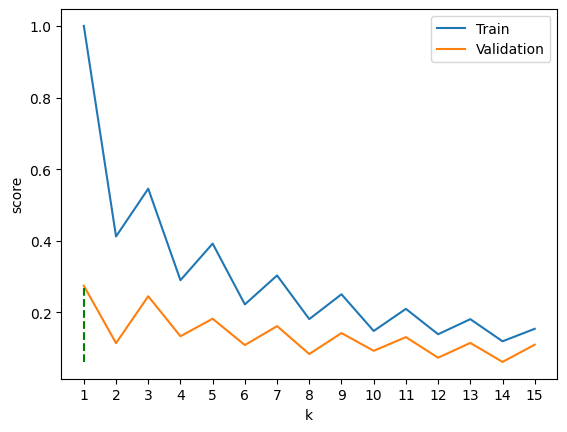

In [284]:
plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()

### No NaN

In [8]:
data_no_nan = data.dropna()

In [9]:
len(data_no_nan) / len(data) *100

17.293510324483776

In [16]:
X_no_nan = data_no_nan.drop('TARGET_B', axis=1).select_dtypes('number')
y_no_nan = data_no_nan['TARGET_B']

In [ ]:
X_train_t, X_val_no_nan, y_train_no_nan, y_val_no_nan = train_test_split(X_no_nan, y_no_nan, test_size=0.2, shuffle=True, stratify=y_no_nan, random_state=42)

In [11]:
result_df = run_parameter_search(grid=param_grid, cv=skf_test, X=X_no_nan, y=y_no_nan, model=pipe, metrics=['f1', 'accuracy',
                                    'precision', 'recall'])
result_df

NameError: name 'run_parameter_search' is not defined

## Ignore for now

In [ ]:
k_list = np.arange(1, 20)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in k_list:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_no_nan, y_train_no_nan)
    train_pred = knn_model.predict(X_train_no_nan)
    val_pred = knn_model.predict(X_val_t)
    scores_train.append(f1_score(y_train_no_nan, train_pred))
    scores_val.append(f1_score(y_val_no_nan, val_pred))
    if(f1_score(y_val_no_nan, val_pred)>high_score):
        high_score = f1_score(y_val_no_nan, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

Best number of neighbors: 1
Mean F1 score in train with 1 neighbors: 1.000000
Mean F1 score in validation with 1 neighbors: 0.284553


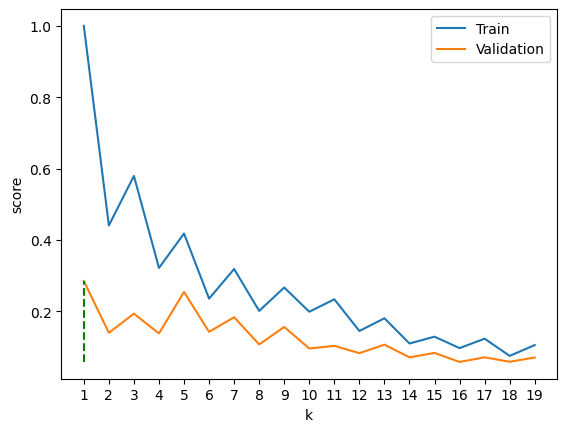

In [23]:
plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()